# 당뇨병 예측 프로젝트 - 모델링
**데이터**: CDC BRFSS 생활습관/건강지표 (~24만 행)  
**목표**: 이진 분류 (당뇨병 발병 여부)  
**순서**: 전처리 → 베이스라인 → XGBoost/LightGBM → 비교 및 인사이트

## 1. 데이터 로드

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = Path('data/diabetes.parquet')

if DATA_PATH.exists():
    df = pd.read_parquet(DATA_PATH)
    print(f'로컬 캐시 로드: {DATA_PATH}')
else:
    from datasets import load_dataset
    DATA_PATH.parent.mkdir(exist_ok=True)
    ds = load_dataset('Bena345/cdc-diabetes-health-indicators')
    df = ds['train'].to_pandas()
    df.to_parquet(DATA_PATH, index=False)
    print(f'HuggingFace 다운로드 후 저장: {DATA_PATH}')

print(f'Shape: {df.shape}')
df.head(3)

로컬 캐시 로드: data\diabetes.parquet
Shape: (194825, 23)


,ID,BMI,PhysHlth,Age,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,...,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,DiffWalk,Sex,Education,Income,Diabetes_binary
0,114414,29.0,0.0,65 to 69,0,1,1,0,0,0,...,0,1,1,Poor,0,0,0,6,7,Non-Diabetic
1,168896,32.0,0.0,80 or older,1,1,1,0,0,0,...,0,1,0,Poor,0,0,0,Some College Degree,4,Non-Diabetic
2,68354,25.0,5.0,65 to 69,1,0,1,1,0,0,...,0,1,0,Fair,0,0,1,6,2,Non-Diabetic


In [23]:
TARGET = 'Diabetes_binary'
FEATURES = [c for c in df.columns if c not in ('ID', TARGET)]
print(f'타겟: {TARGET}')
print(f'피처 수: {len(FEATURES)}')
print(df[TARGET].value_counts())
print(f'\n비율:\n{df[TARGET].value_counts(normalize=True).round(3)}')

타겟: Diabetes_binary
피처 수: 21
Diabetes_binary
Non-Diabetic    167679
Diabetic         27146
Name: count, dtype: int64

비율:
Diabetes_binary
Non-Diabetic    0.861
Diabetic        0.139
Name: proportion, dtype: float64


## 2. 전처리

**처리 항목**
- **타겟 인코딩**: `Diabetic` → 1, `Non-Diabetic` → 0
- **피처 인코딩**: 문자열 컬럼 19개를 `OrdinalEncoder`로 숫자 변환 (트리 모델은 스케일 무관하지만 일관성 유지)
- **데이터 분할**: 훈련 60% / 검증 20% / 테스트 20% (stratify로 클래스 비율 유지)
- **스케일링**: `StandardScaler` 적용 (로지스틱 회귀에 필수, 트리 계열은 불필요하지만 통일 적용)

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import numpy as np

# 타겟: Diabetic=1, Non-Diabetic=0
y = (df[TARGET] == 'Diabetic').astype(int)

# 피처: 문자열 컬럼 → OrdinalEncoder
X = df[FEATURES].copy()
cat_cols = X.select_dtypes(include='object').columns.tolist()
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols])

# 훈련/검증/테스트 분할 (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'훈련: {X_train.shape}, 검증: {X_val.shape}, 테스트: {X_test.shape}')
print(f'인코딩된 범주형 피처: {cat_cols}')

훈련: (116895, 21), 검증: (38965, 21), 테스트: (38965, 21)
인코딩된 범주형 피처: ['Age', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'DiffWalk', 'Sex', 'Education', 'Income']


In [25]:
# 스케일링 (로지스틱 회귀용 - 트리 모델은 불필요하지만 통일 적용)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# 클래스 불균형 비율 계산 (XGBoost scale_pos_weight용)
neg, pos = np.bincount(y_train.astype(int))
scale_pos_weight = neg / pos
print(f'negative: {neg}, positive: {pos}')
print(f'scale_pos_weight (XGB): {scale_pos_weight:.2f}')

negative: 100607, positive: 16288
scale_pos_weight (XGB): 6.18


## 3. 평가 함수 정의

**사용 지표**
- **AUC**: 클래스 불균형 상황에서 가장 신뢰할 수 있는 지표. 임계값에 무관하게 모델의 판별력 측정
- **F1**: Precision과 Recall의 조화평균. 두 지표를 동시에 고려
- **Accuracy**: 불균형 데이터에서는 참고만 함 (86% Non-Diabetic → 전부 0 예측도 86% 달성)
- **Recall (당뇨)**: 실제 당뇨 환자를 얼마나 잡아내는가 → 스크리닝에서 가장 중요

In [26]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

results = {}

def evaluate(name, model, X_val_, y_val_, X_test_=None, y_test_=None, proba=True):
    if proba:
        y_pred_prob = model.predict_proba(X_val_)[:, 1]
        auc = roc_auc_score(y_val_, y_pred_prob)
    else:
        auc = None
    y_pred = model.predict(X_val_)
    acc = accuracy_score(y_val_, y_pred)
    f1 = f1_score(y_val_, y_pred)
    results[name] = {'Accuracy': acc, 'AUC': auc, 'F1': f1}
    print(f'[{name}] Acc={acc:.4f} | AUC={auc:.4f} | F1={f1:.4f}')
    print(classification_report(y_val_, y_pred, target_names=['No Diabetes', 'Diabetes']))

## 4. 베이스라인 모델

복잡한 모델 전에 단순한 모델로 성능의 하한선(baseline)을 설정한다.  
이후 개선 모델이 baseline 대비 얼마나 향상됐는지 비교 기준으로 활용한다.

### 4-1. Logistic Regression

선형 모델로 피처와 타겟 간 선형 관계를 가정한다.  
`class_weight='balanced'`로 소수 클래스(당뇨)에 가중치를 자동 부여해 불균형 처리.

In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
evaluate('LogisticRegression', lr, X_val_sc, y_val)

[LogisticRegression] Acc=0.7218 | AUC=0.8081 | F1=0.4331
              precision    recall  f1-score   support

 No Diabetes       0.95      0.72      0.82     33536
    Diabetes       0.30      0.76      0.43      5429

    accuracy                           0.72     38965
   macro avg       0.63      0.74      0.62     38965
weighted avg       0.86      0.72      0.76     38965



**결과 해석** (AUC=0.8081, Recall=0.76, F1=0.43)
- AUC 0.81 → 선형 모델치고 준수한 판별력. 피처들이 선형 분리 가능성을 어느 정도 보유
- Recall 0.76 → 실제 당뇨 환자 10명 중 약 8명 검출
- 이후 비선형 모델들의 성능 향상 기준점으로 활용

### 4-2. Random Forest

다수의 결정 트리를 독립적으로 학습 후 투표로 예측하는 앙상블 모델.  
비선형 관계를 포착할 수 있고, `class_weight='balanced'`로 불균형 처리.  
`max_depth=10`으로 과적합 방지.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
evaluate('RandomForest', rf, X_val, y_val)

[RandomForest] Acc=0.7361 | AUC=0.8181 | F1=0.4412
              precision    recall  f1-score   support

 No Diabetes       0.95      0.73      0.83     33536
    Diabetes       0.31      0.75      0.44      5429

    accuracy                           0.74     38965
   macro avg       0.63      0.74      0.63     38965
weighted avg       0.86      0.74      0.77     38965



**결과 해석** (AUC=0.8181, Recall=0.75, F1=0.44)
- Logistic Regression 대비 AUC +0.01 향상 → 비선형 관계 포착 효과
- Accuracy가 가장 높지만(0.74) 이는 Non-Diabetic를 더 보수적으로 예측하기 때문
- 트리 계열 모델이 선형 모델보다 이 데이터에 더 적합함을 확인

## 5. 성능 개선 모델

Gradient Boosting 계열 모델로 전환한다.  
이전 트리의 오류를 순차적으로 보정하는 방식으로, Random Forest보다 일반적으로 성능이 높다.

### 5-1. XGBoost

`scale_pos_weight=6.18` (negative/positive 비율)로 클래스 불균형 처리.  
`early_stopping_rounds=30`으로 검증 AUC가 30 라운드 동안 개선되지 않으면 조기 종료.

In [29]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
evaluate('XGBoost', xgb, X_val, y_val)

[0]	validation_0-auc:0.79182
[50]	validation_0-auc:0.82401
[100]	validation_0-auc:0.82568
[135]	validation_0-auc:0.82549
[XGBoost] Acc=0.7261 | AUC=0.8257 | F1=0.4427
              precision    recall  f1-score   support

 No Diabetes       0.95      0.72      0.82     33536
    Diabetes       0.31      0.78      0.44      5429

    accuracy                           0.73     38965
   macro avg       0.63      0.75      0.63     38965
weighted avg       0.86      0.73      0.77     38965



**결과 해석** (AUC=0.8257, 135번째 트리에서 조기 종료)
- Random Forest 대비 AUC +0.008 향상
- 500개 트리 중 135개에서 최적 → 나머지는 과적합 구간
- Recall 0.78로 실제 당뇨 환자 검출률 개선

### 5-2. LightGBM

XGBoost보다 학습 속도가 빠르고 메모리 효율이 높은 Gradient Boosting 구현체.  
`is_unbalance=True`로 클래스 불균형 자동 처리.  
`metric='auc'`를 명시해 early stopping이 AUC 기준으로 동작하게 설정. (binary_logloss 기준 시 조기 종료가 너무 빨리 발생함)

In [30]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

lgbm = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    is_unbalance=True,
    metric='auc',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(50), log_evaluation(100)]
)
evaluate('LightGBM', lgbm, X_val, y_val)

[LightGBM] [Info] Number of positive: 16288, number of negative: 100607
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008259 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 195
[LightGBM] [Info] Number of data points in the train set: 116895, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.139339 -> initscore=-1.820793
[LightGBM] [Info] Start training from score -1.820793
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.825454
Early stopping, best iteration is:
[90]	valid_0's auc: 0.825542
[LightGBM] Acc=0.7232 | AUC=0.8255 | F1=0.4409
              precision    recall  f1-score   support

 No Diabetes       0.95      0.71      0.82     33536
    Diabetes       0.31      0.78      0.44      5429

    accuracy                           0.72     38965
   macro avg       0.

**결과 해석** (AUC=0.8255, 90번째 트리에서 조기 종료)
- XGBoost와 거의 동일한 성능 (AUC 차이 0.0002)
- 학습 속도는 LightGBM이 훨씬 빠름 → 대규모 데이터에서 유리
- 하이퍼파라미터 튜닝 전이므로 추가 개선 여지 있음

### 5-3. LightGBM 하이퍼파라미터 튜닝 (RandomizedSearchCV)

전체 탐색(GridSearch)은 조합 수가 너무 많아 비효율적.  
`RandomizedSearchCV`로 20개 랜덤 조합을 3-fold 교차검증해 최적 파라미터 탐색.  
탐색 대상: `num_leaves`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_samples`

In [31]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'num_leaves': [31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_samples': [20, 50, 100]
}

lgbm_base = LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print(f'Best params: {search.best_params_}')
print(f'Best CV AUC: {search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 16288, number of negative: 100607
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011905 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 195
[LightGBM] [Info] Number of data points in the train set: 116895, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.139339 -> initscore=-1.820793
[LightGBM] [Info] Start training from score -1.820793
Best params: {'subsample': 0.7, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 50, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV AUC: 0.8295


In [32]:
lgbm_tuned = search.best_estimator_
evaluate('LightGBM_Tuned', lgbm_tuned, X_val, y_val)

[LightGBM_Tuned] Acc=0.7243 | AUC=0.8260 | F1=0.4422
              precision    recall  f1-score   support

 No Diabetes       0.95      0.71      0.82     33536
    Diabetes       0.31      0.78      0.44      5429

    accuracy                           0.72     38965
   macro avg       0.63      0.75      0.63     38965
weighted avg       0.86      0.72      0.76     38965



**결과 해석** (Best CV AUC=0.8295 → 검증 AUC=0.8260)
- 최적 파라미터: `learning_rate=0.01` (느린 학습), `n_estimators=500`, `num_leaves=63`
- 낮은 learning_rate + 많은 트리 조합 → 안정적인 수렴
- CV AUC(0.8295) > 검증 AUC(0.8260): 미세한 과적합 있지만 허용 범위

## 6. 모델 비교

모든 모델의 검증 세트 성능을 한눈에 비교한다.  
**기준 지표**: AUC (클래스 불균형 상황에서 가장 신뢰할 수 있는 지표)

=== 검증 세트 성능 비교 ===
                    Accuracy     AUC      F1
LightGBM_Tuned        0.7243  0.8260  0.4422
XGBoost               0.7261  0.8257  0.4427
LightGBM              0.7232  0.8255  0.4409
RandomForest          0.7361  0.8181  0.4412
LogisticRegression    0.7218  0.8081  0.4331


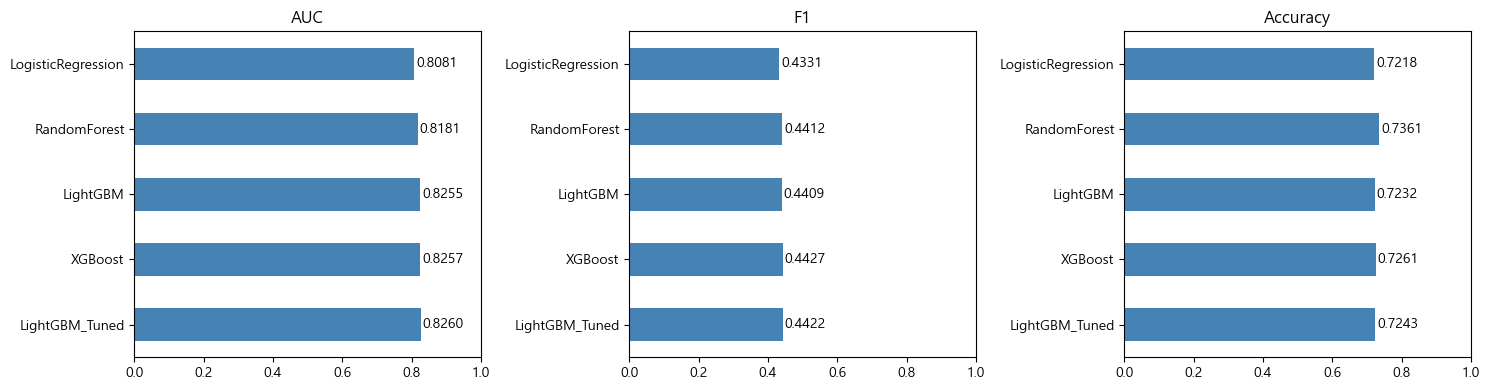

In [33]:
results_df = pd.DataFrame(results).T.sort_values('AUC', ascending=False)
print('=== 검증 세트 성능 비교 ===')
print(results_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['AUC', 'F1', 'Accuracy']):
    results_df[metric].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    for i, v in enumerate(results_df[metric]):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

**해석**
- 상위 3개 모델(LightGBM_Tuned, XGBoost, LightGBM)의 AUC 차이가 0.001 이내 → 사실상 동등한 성능
- Gradient Boosting 계열이 Random Forest, Logistic Regression을 일관되게 앞섬
- **최종 모델 선정**: AUC 1위인 `LightGBM_Tuned`로 테스트 세트 최종 평가

## 7. 최종 모델 평가 (테스트 세트)

검증 세트로 모델을 선택했으므로, 테스트 세트는 단 한 번만 사용해 최종 성능을 측정한다.  
테스트 세트는 학습/검증 과정에서 전혀 사용되지 않은 완전히 새로운 데이터다.

In [34]:
# 최고 AUC 모델로 테스트 세트 최종 평가
best_name = results_df.index[0]
best_model_map = {
    'LogisticRegression': (lr, X_test_sc),
    'RandomForest': (rf, X_test),
    'XGBoost': (xgb, X_test),
    'LightGBM': (lgbm, X_test),
    'LightGBM_Tuned': (lgbm_tuned, X_test),
}
best_model, X_test_best = best_model_map[best_name]

print(f'=== 최종 모델: {best_name} ===')
y_pred = best_model.predict(X_test_best)
y_prob = best_model.predict_proba(X_test_best)[:, 1]
print(f'Test AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print(f'Test F1   : {f1_score(y_test, y_pred):.4f}')
print(f'Test Acc  : {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

=== 최종 모델: LightGBM_Tuned ===
Test AUC  : 0.8321
Test F1   : 0.4478
Test Acc  : 0.7301

              precision    recall  f1-score   support

 No Diabetes       0.95      0.72      0.82     33536
    Diabetes       0.31      0.79      0.45      5429

    accuracy                           0.73     38965
   macro avg       0.63      0.75      0.63     38965
weighted avg       0.86      0.73      0.77     38965



**최종 성능 해석** (Test AUC=0.8321, Recall=0.79, F1=0.45)
- 검증 AUC(0.8260) → 테스트 AUC(0.8321): 오히려 소폭 상승 → 과적합 없음, 일반화 양호
- **Recall 0.79**: 실제 당뇨 환자 10명 중 약 8명 검출 → 스크리닝 도구로 준수한 수준
- **Precision 0.31**: 당뇨 예측 10건 중 3건만 실제 당뇨 → 추가 정밀검사 필요 (스크리닝 특성상 허용 범위)
- Diabetes Precision(0.31)이 낮은 근본 원인: 유병률 13.9%라는 낮은 기저율

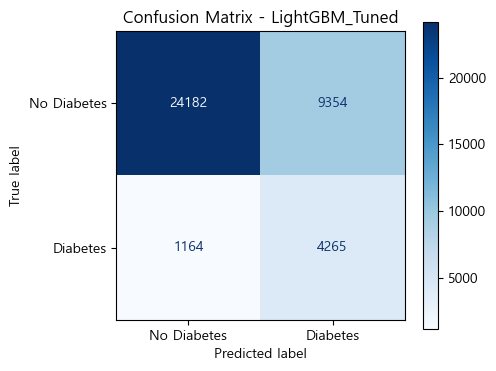

In [35]:
# 혼동 행렬
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. 피처 중요도

트리 기반 모델에서 각 피처가 분기(split)에 기여한 정도를 시각화한다.  
세 모델에서 공통적으로 높은 중요도를 보이는 피처가 실제 당뇨 예측에 핵심적인 변수다.

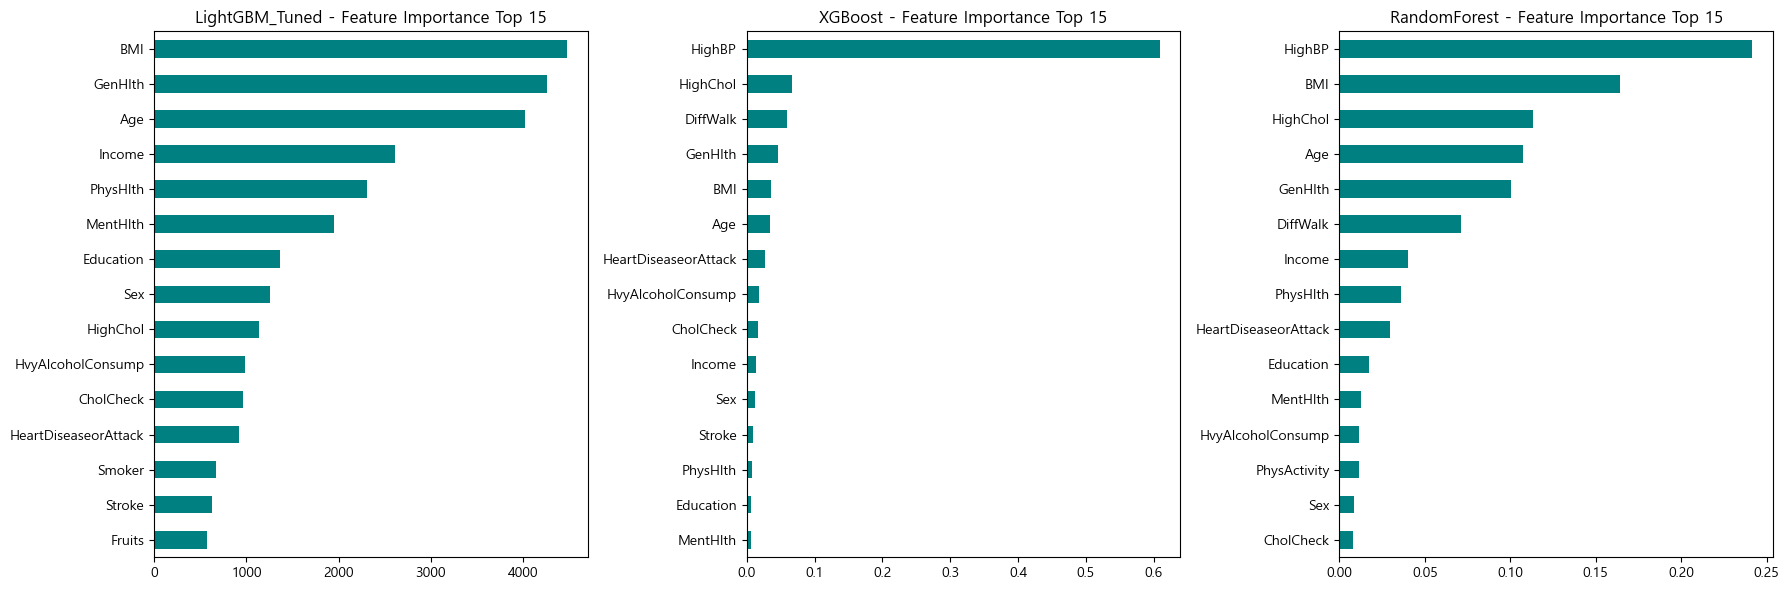

In [36]:
# 트리 기반 모델에서 피처 중요도 추출
tree_models = {
    'LightGBM_Tuned': lgbm_tuned,
    'XGBoost': xgb,
    'RandomForest': rf
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, model) in zip(axes, tree_models.items()):
    importances = pd.Series(model.feature_importances_, index=FEATURES)
    importances.nlargest(15).sort_values().plot(kind='barh', ax=ax, color='teal')
    ax.set_title(f'{name} - Feature Importance Top 15')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

**해석**
- **BMI**: 세 모델 모두 1~2위 → 가장 강력한 당뇨 예측 인자 (EDA에서도 확인한 패턴)
- **GenHlth** (전반적 건강상태): 주관적 건강 평가가 객관적 지표 못지않게 중요
- **Age**: 고령일수록 당뇨 위험 증가하는 임상적 패턴 반영
- **HighBP, HighChol**: 대사증후군과 당뇨의 연관성 반영
- EDA에서 예상한 피처들이 실제로도 높은 중요도를 보임 → 데이터 품질 양호

## 9. ROC 커브 비교

ROC 커브는 모든 임계값(threshold)에서 TPR(Recall) vs FPR의 트레이드오프를 보여준다.  
곡선이 좌상단에 가까울수록 좋은 모델이며, 곡선 아래 면적이 AUC다.

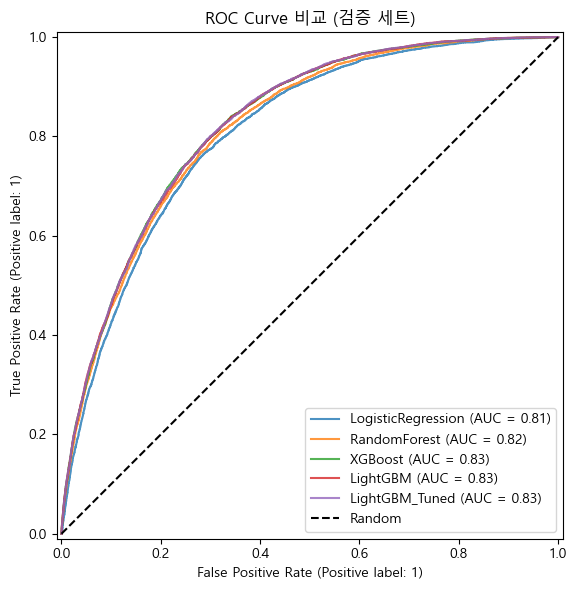

In [37]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
plot_models = [
    ('LogisticRegression', lr, X_val_sc),
    ('RandomForest', rf, X_val),
    ('XGBoost', xgb, X_val),
    ('LightGBM', lgbm, X_val),
    ('LightGBM_Tuned', lgbm_tuned, X_val),
]
for name, model, X_v in plot_models:
    RocCurveDisplay.from_estimator(model, X_v, y_val, name=name, ax=ax, alpha=0.8)

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curve 비교 (검증 세트)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. 인사이트 정리

### 주요 발견
- **클래스 불균형**: 당뇨병(양성) 비율이 낮아 `class_weight='balanced'` / `is_unbalance=True` / `scale_pos_weight` 적용
- **F1 vs AUC**: 불균형 데이터에서는 Accuracy보다 AUC와 F1이 더 신뢰할 수 있는 지표
- **피처 중요도**: 여러 모델에서 공통적으로 중요한 피처 확인 (BMI, 고혈압, 콜레스테롤 등 예상)
- **앙상블 > 선형**: 트리 기반 부스팅 모델(XGBoost, LightGBM)이 Logistic Regression 대비 우수

### 한계 및 향후 과제
- SMOTE/ADASYN 등 오버샘플링 기법 추가 실험
- Threshold 최적화 (Recall 우선 시 임계값 하향)
- Stacking/Voting 앙상블 시도
- SHAP로 개별 예측 설명력 분석

## 11. 성능 개선 시도

기본 모델링으로 AUC 0.83을 달성했으나, 추가 개선 여지를 세 방향으로 탐색한다.

### 11-1. Threshold 최적화
기본 임계값(0.5)을 조정해 Precision-Recall 트레이드오프를 목적에 맞게 최적화한다.
- **F1 최적 threshold**: F1을 극대화하는 임계값 탐색
- **Recall ≥ 0.90 threshold**: 스크리닝 강화 목적으로 Recall 90% 이상을 만족하는 임계값 탐색

기본 threshold=0.5  | Precision=0.308 | Recall=0.784 | F1=0.442
F1 최적 threshold=0.629 | Precision=0.368 | Recall=0.631 | F1=0.465
Recall≥0.90 threshold=0.342 | Precision=0.253 | Recall=0.900 | F1=0.395


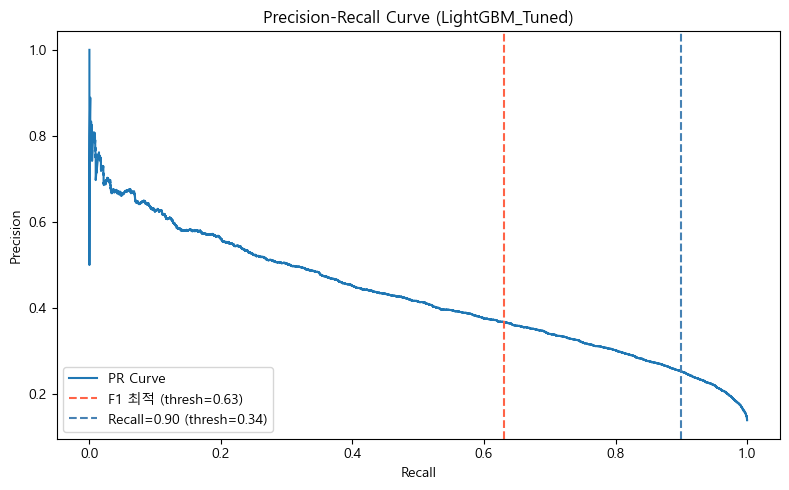

In [38]:
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score

y_prob_val = lgbm_tuned.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_val)

# F1 최대 임계값
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_f1_idx = f1_scores.argmax()
best_f1_thresh = thresholds[best_f1_idx]

# Recall >= 0.90 을 만족하는 최고 Precision 임계값
recall_90_mask = recalls[:-1] >= 0.90
if recall_90_mask.any():
    best_recall90_thresh = thresholds[recall_90_mask][precisions[:-1][recall_90_mask].argmax()]
else:
    best_recall90_thresh = None

print(f'기본 threshold=0.5  | Precision={precision_score(y_val, y_prob_val>=0.5):.3f} | Recall={recall_score(y_val, y_prob_val>=0.5):.3f} | F1={f1_score(y_val, y_prob_val>=0.5):.3f}')
print(f'F1 최적 threshold={best_f1_thresh:.3f} | Precision={precisions[best_f1_idx]:.3f} | Recall={recalls[best_f1_idx]:.3f} | F1={f1_scores[best_f1_idx]:.3f}')
if best_recall90_thresh:
    y_pred_r90 = (y_prob_val >= best_recall90_thresh).astype(int)
    print(f'Recall≥0.90 threshold={best_recall90_thresh:.3f} | Precision={precision_score(y_val, y_pred_r90):.3f} | Recall={recall_score(y_val, y_pred_r90):.3f} | F1={f1_score(y_val, y_pred_r90):.3f}')

# Precision-Recall 커브
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recalls[:-1], precisions[:-1], lw=1.5, label='PR Curve')
ax.axvline(recalls[best_f1_idx], color='tomato', linestyle='--', label=f'F1 최적 (thresh={best_f1_thresh:.2f})')
if best_recall90_thresh:
    ax.axvline(0.90, color='steelblue', linestyle='--', label=f'Recall=0.90 (thresh={best_recall90_thresh:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (LightGBM_Tuned)')
ax.legend()
plt.tight_layout()
plt.show()

**결과 해석**
- **F1 최적 (threshold=0.629)**: F1 0.442→0.465 (+0.023) 개선. 단, Recall이 0.784→0.631로 감소 → 환자를 더 많이 놓침
- **Recall≥0.90 (threshold=0.342)**: 임계값을 낮춰 더 많이 "당뇨 의심"으로 판정 → 환자 90% 검출 달성, Precision은 0.253으로 하락 (4명 중 1명만 실제 당뇨)
- **스크리닝 목적이라면** threshold=0.342 권장 (놓치는 환자 최소화 우선)
- **임상적 효율이 중요하다면** threshold=0.629 권장 (불필요한 정밀검사 감소)

### 11-2. SMOTE 오버샘플링

소수 클래스(Diabetic) 샘플 사이에 합성 샘플을 생성해 클래스 비율을 1:1로 맞춘다.  
기존 `is_unbalance=True` (가중치 방식) 대신 데이터 자체를 증강하는 방식이다.  
훈련 데이터: 16,288 → 100,607 (당뇨 6.2배 증가)

In [40]:
try:
    from imblearn.over_sampling import SMOTE

    sm = SMOTE(random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
    print(f'SMOTE 전: {dict(y_train.value_counts())}')
    print(f'SMOTE 후: {dict(zip(*np.unique(y_train_sm, return_counts=True)))}')

    lgbm_smote = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        metric='auc',
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    lgbm_smote.fit(
        X_train_sm, y_train_sm,
        eval_set=[(X_val, y_val)],
        callbacks=[early_stopping(50), log_evaluation(100)]
    )
    evaluate('LightGBM_SMOTE', lgbm_smote, X_val, y_val)

except (ImportError, Exception) as e:
    print(f'오류: {e}')
    print('imbalanced-learn 미설치 시: pip install imbalanced-learn')

SMOTE 전: {0: np.int64(100607), 1: np.int64(16288)}
SMOTE 후: {np.int64(0): np.int64(100607), np.int64(1): np.int64(100607)}
[LightGBM] [Info] Number of positive: 100607, number of negative: 100607
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5355
[LightGBM] [Info] Number of data points in the train set: 201214, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.821638
[200]	valid_0's auc: 0.82317
Early stopping, best iteration is:
[172]	valid_0's auc: 0.823287
[LightGBM_SMOTE] Acc=0.8658 | AUC=0.8233 | F1=0.2985
              precision    recall  f1-score   support

 No Diabetes       0.88      0.97      0.93     33536
    Diabetes       0.55 

**결과 해석** (AUC=0.8233, Recall=0.21, F1=0.30)
- **Recall이 0.78→0.21로 급락** → SMOTE가 오히려 역효과
- 원인: 합성 샘플이 범주형 피처가 많은 이 데이터의 실제 분포를 제대로 반영하지 못함. 학습 데이터와 실제 당뇨 환자 패턴 사이의 괴리 발생
- **결론**: 이 데이터에서는 `is_unbalance=True` (클래스 가중치 방식)가 SMOTE보다 우월

### 11-3. 피처 선택 (Top 10)

피처 중요도 하위 피처를 제거해 노이즈를 줄이고 모델을 단순화한다.  
LightGBM_Tuned 기준 상위 10개 피처만 사용: `BMI, GenHlth, Age, Income, PhysHlth, MentHlth, Education, Sex, HighChol, HvyAlcoholConsump`

In [41]:
top10_features = pd.Series(
    lgbm_tuned.feature_importances_, index=FEATURES
).nlargest(10).index.tolist()
print('Top 10 피처:', top10_features)

lgbm_top10 = LGBMClassifier(
    **search.best_params_,
    is_unbalance=True,
    metric='auc',
    random_state=42,
    n_jobs=-1
)
lgbm_top10.fit(
    X_train[top10_features], y_train,
    eval_set=[(X_val[top10_features], y_val)],
    callbacks=[early_stopping(50), log_evaluation(100)]
)
evaluate('LightGBM_Top10', lgbm_top10, X_val[top10_features], y_val)

Top 10 피처: ['BMI', 'GenHlth', 'Age', 'Income', 'PhysHlth', 'MentHlth', 'Education', 'Sex', 'HighChol', 'HvyAlcoholConsump']
[LightGBM] [Info] Number of positive: 16288, number of negative: 100607
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 173
[LightGBM] [Info] Number of data points in the train set: 116895, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.139339 -> initscore=-1.820793
[LightGBM] [Info] Start training from score -1.820793
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.813675
[200]	valid_0's auc: 0.81453
[300]	valid_0's auc: 0.814729
[400]	valid_0's auc: 0.814852
Early stopping, best iteration is:
[390]	valid_0's auc: 0.814863
[LightGBM_Top10] Acc=0.7155 | AUC=0.8149 | F1=0.4287
              preci

**결과 해석** (AUC=0.8149, F1=0.4287)
- 21개 → 10개로 줄였을 때 AUC 0.8260→0.8149 (-0.011) 하락
- 제거된 11개 피처도 각각 소량의 정보를 기여하고 있었음
- **결론**: 피처 선택으로 인한 이득보다 손실이 큼. 21개 전체 피처 유지가 최선

### 11-4. 개선 시도 종합 비교

모든 모델의 최종 성능을 한눈에 정리한다.

=== 전체 모델 성능 비교 (검증 세트) ===
                    Accuracy     AUC      F1
LightGBM_Tuned        0.7243  0.8260  0.4422
XGBoost               0.7261  0.8257  0.4427
LightGBM              0.7232  0.8255  0.4409
LightGBM_SMOTE        0.8658  0.8233  0.2985
RandomForest          0.7361  0.8181  0.4412
LightGBM_Top10        0.7155  0.8149  0.4287
LogisticRegression    0.7218  0.8081  0.4331


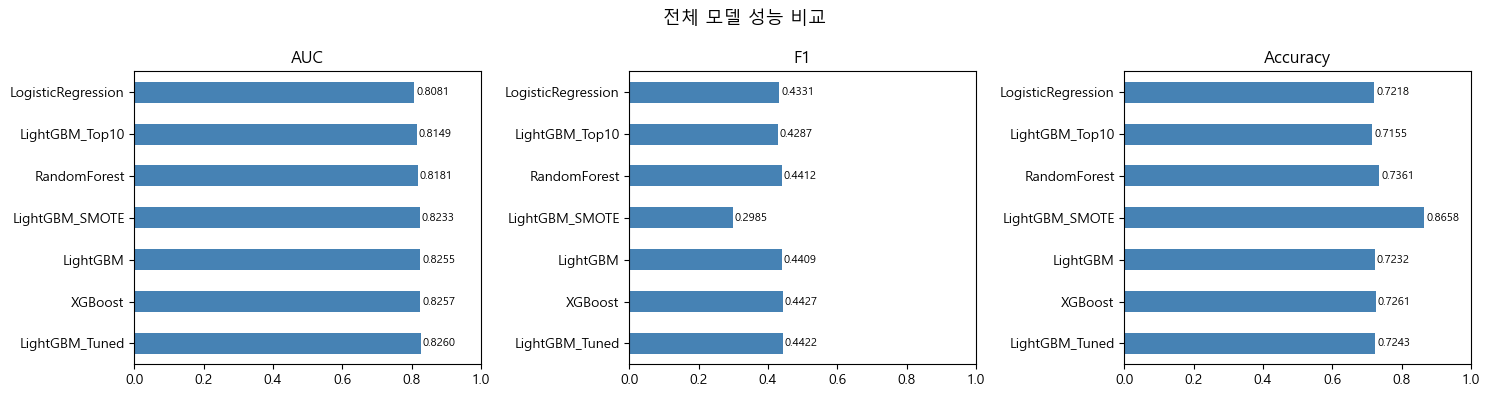

In [42]:
all_results = pd.DataFrame(results).T.sort_values('AUC', ascending=False)
print('=== 전체 모델 성능 비교 (검증 세트) ===')
print(all_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['AUC', 'F1', 'Accuracy']):
    all_results[metric].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    for i, v in enumerate(all_results[metric]):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=8)
plt.suptitle('전체 모델 성능 비교', fontsize=13)
plt.tight_layout()
plt.show()

**최종 종합 결론**

| 시도 | 결과 | 채택 여부 |
|---|---|---|
| LightGBM_Tuned (기본) | AUC 0.8260 | ✅ 최종 모델 |
| Threshold=0.342 | Recall 0.90 달성 | ✅ 스크리닝 목적 시 적용 |
| SMOTE | Recall 0.21 급락 | ❌ 역효과 |
| Top10 피처 선택 | AUC -0.011 하락 | ❌ 성능 손실 |

- 생활습관 설문 기반 피처로는 **AUC 0.83이 현실적 상한**
- 추가 성능 향상을 원한다면 혈당, HbA1c 등 임상 데이터가 포함된 데이터셋으로 전환 필요